In [53]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from config import coordonate_extinse


from sklearn.linear_model import Lasso, LinearRegression, Ridge, RidgeCV

from sklearn import metrics
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor, RandomForestRegressor, StackingRegressor, VotingRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
from scipy.stats import uniform, randint

from category_encoders import BinaryEncoder

from sklearn.model_selection import TimeSeriesSplit



 

Descarcam datasetul.

In [2]:
# Download latest version
path = kagglehub.dataset_download("raghavramasamy/crop-statistics-fao-all-countries")

print("Path to dataset files:", path)

100%|██████████| 24.3M/24.3M [00:02<00:00, 11.3MB/s]

Extracting files...


Path to dataset files: C:\Users\apop3\.cache\kagglehub\datasets\raghavramasamy\crop-statistics-fao-all-countries\versions\3


Pastram doar datele pentru mere.

In [20]:
# 1. Încarcă fișierul original (asigură-te că folosești encoding-ul corect)
df = pd.read_csv("Crops_AllData_Normalized.csv", encoding='latin-1')

# 2. Filtrează strict pentru Mere
# Folosim .str.contains pentru a fi siguri că prindem orice variație (ex: "Apples")
df_mere = df[df['Item'] == 'Apples']

# 3. Salvează noul dataset într-un fișier CSV separat
# Folosim encoding='utf-8-sig' pentru a ne asigura că Excel îl deschide corect ulterior
df_mere.to_csv("FAO_Mere_Global.csv", index=False, encoding='utf-8-sig')

print("Filtrare finalizată! Fișierul 'FAO_Mere_Global.csv' a fost creat.")
print(f"Număr total de înregistrări salvate: {len(df_mere)}")

Filtrare finalizată! Fișierul 'FAO_Mere_Global.csv' a fost creat.
Număr total de înregistrări salvate: 19022


Verificam cate valori null avem si pe ce coloana sunt acestea.

In [16]:
df.isnull().sum()

Area                          0
Year                          0
Area harvested                0
Production                    0
Yield                         0
Temp_Medie_An                 0
Precip_Tot_An                 0
Zile_Inghet_An                0
Temp_Max_primavara_critica    0
Precip_primavara_critica      0
Inghet_primavara_critica      0
Umid_Sol_primavara_critica    0
Temp_Max_vara_crestere        0
Precip_vara_crestere          0
Inghet_vara_crestere          0
Umid_Sol_vara_crestere        0
dtype: int64

Verificam pentru ce ani se poate face interpolare. 

In [16]:
df_mere = pd.read_csv("FAO_Mere_Global.csv", encoding='utf-8-sig')

# Presupunem că df_mere este datasetul tău
# Sortăm datele după zonă și an pentru a avea serii cronologice corecte
df_mere = df_mere.sort_values(['Area', 'Year'])

# Verificăm unde avem valori nule care NU pot fi interpolate (cele de la începutul seriei fiecărei țări)
def verifica_neinterpolabile(seria):
    # Interpolăm temporar
    interp = seria.interpolate(method='linear')
    # Returnăm True acolo unde era NaN și a rămas NaN după interpolare
    return seria.isna() & interp.isna()

df_mere['is_unfixable'] = df_mere.groupby('Area')['Value'].transform(verifica_neinterpolabile)

# Vedem care este ultimul an din tot datasetul care are astfel de probleme
ultimul_an_problematic = df_mere[df_mere['is_unfixable'] == True]['Year'].max()

print(f"Până în anul {ultimul_an_problematic} avem date care nu pot fi "
      "reparate prin interpolare (lipsesc de la începutul seriilor).")

Până în anul 2004 avem date care nu pot fi reparate prin interpolare (lipsesc de la începutul seriilor).


Eliminam anii pentru care nu se poate face interpolare.

In [ ]:
df_mere = pd.read_csv("Dataset_Mere.csv", encoding='utf-8-sig')

df_mere = df_mere[df_mere['Year'] > 2004]

df_mere.to_csv("Dataset_Mere_Curat.csv", index=False, encoding='utf-8-sig')

Eliminam coloanele care nu aduc nicio informatie utila. 

In [ ]:
df_mere.drop(columns=['Area Code', 'Item Code', 'Element Code', 'Year Code', 'Item', 'Flag'], inplace=True)


# 4. Salvăm noul dataset
df_mere.to_csv("Dataset_Mere_Final.csv", index=False, encoding='utf-8-sig')


In [31]:
df_mere.isnull().sum()

Area       0
Element    0
Year       0
Unit       0
Value      0
dtype: int64

Punem tipul de masurare a valorii in coloane separate. Area harvested, production, etc.

In [ ]:
# Transformă tabelul pentru ML (un singur rând pentru fiecare țară și an)
df_final = df_mere.pivot_table(
    index=['Area', 'Year'], 
    columns='Element', 
    values='Value'
).reset_index()

# Salvează varianta gata de antrenare
df_final.to_csv("Dataset_Mere_Final.csv", index=False, encoding='utf-8-sig')

Am verificat ce zone lipsesc din dictionarul de coordonate.

In [ ]:
tari_in_dataset = set(df_final["Area"].unique())
tari_cu_coords  = set(coordonate_extinse.keys())

lipsa = tari_in_dataset - tari_cu_coords
print(f"Îți lipsesc {len(lipsa)} regiuni/țări:")
for t in sorted(lipsa):
    print(f"  - {t}")

Verificam diferneta dintre numele zonelor din dictionarul cu coordonate si numele din datasetul nostru

In [ ]:
perechi_de_verificat = ["Syria", "Moldova", "Bolivia", "Korea", "China", "United Kingdom"]

for termen in perechi_de_verificat:
    rezultate = [x for x in df_final["Area"].unique() if termen in x]
    print(f"{termen}: {rezultate}")

In scriptul "clima" am extras datele de clima pentru regiunile pe care am decis sa le pastrez si am dat merge cu datasetul de productie.


Verificam valorile nulle si duplicatele in noul dataset.

In [40]:
df = pd.read_csv("Dataset_Mere_Clima_Final.csv", encoding='utf-8-sig')

# Verificăm dacă avem valori nule în coloanele relevante
print(df.isnull().sum())

Area                           0
Year                           0
Area harvested                15
Production                     0
Yield                         15
Temp_Medie_An                  0
Precip_Tot_An                  0
Zile_Inghet_An                 0
Temp_Max_primavara_critica     0
Precip_primavara_critica       0
Inghet_primavara_critica       0
Umid_Sol_primavara_critica     0
Temp_Max_vara_crestere         0
Precip_vara_crestere           0
Inghet_vara_crestere           0
Umid_Sol_vara_crestere         0
dtype: int64


In [41]:
# Numără câte rânduri sunt duplicate complet
print(f"Număr rânduri duplicate: {df.duplicated().sum()}")

# Afișează rândurile duplicate (pentru a le vedea)
print(df[df.duplicated()])

Număr rânduri duplicate: 0
Empty DataFrame
Columns: [Area, Year, Area harvested, Production, Yield, Temp_Medie_An, Precip_Tot_An, Zile_Inghet_An, Temp_Max_primavara_critica, Precip_primavara_critica, Inghet_primavara_critica, Umid_Sol_primavara_critica, Temp_Max_vara_crestere, Precip_vara_crestere, Inghet_vara_crestere, Umid_Sol_vara_crestere]
Index: []


Eliminam randurile cu valori null si mai verific odata.


In [42]:
df.dropna(subset=['Area harvested', 'Yield'], inplace=True)

df.isnull().sum()

Area                          0
Year                          0
Area harvested                0
Production                    0
Yield                         0
Temp_Medie_An                 0
Precip_Tot_An                 0
Zile_Inghet_An                0
Temp_Max_primavara_critica    0
Precip_primavara_critica      0
Inghet_primavara_critica      0
Umid_Sol_primavara_critica    0
Temp_Max_vara_crestere        0
Precip_vara_crestere          0
Inghet_vara_crestere          0
Umid_Sol_vara_crestere        0
dtype: int64

Verificam ce procent de valori de '0' avem pe fiecare coloana.

In [43]:
# Calculăm procentul de zerouri pentru fiecare coloană
zeros_report = (df == 0).sum() / len(df) * 100
print("Procentul de valori 0 în fiecare coloană:")
print(zeros_report.sort_values(ascending=False))

Procentul de valori 0 în fiecare coloană:
Inghet_vara_crestere          91.218949
Inghet_primavara_critica      44.136337
Zile_Inghet_An                30.733680
Precip_vara_crestere           5.314847
Precip_primavara_critica       0.404391
Area                           0.000000
Area harvested                 0.000000
Year                           0.000000
Precip_Tot_An                  0.000000
Temp_Medie_An                  0.000000
Yield                          0.000000
Production                     0.000000
Umid_Sol_primavara_critica     0.000000
Temp_Max_primavara_critica     0.000000
Temp_Max_vara_crestere         0.000000
Umid_Sol_vara_crestere         0.000000
dtype: float64


Verificam corelatia

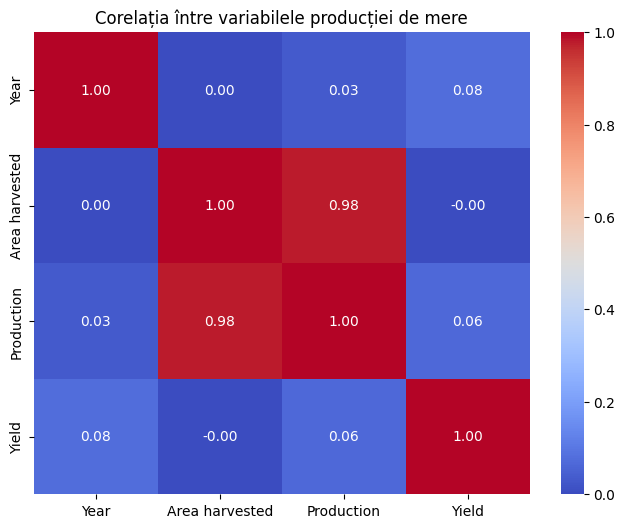

In [44]:
# Calculăm matricea de corelație (doar pentru coloanele numerice)
corr = df[['Year', 'Area harvested', 'Production', 'Yield']].corr()

# Desenăm o hartă termică (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corelația între variabilele producției de mere")
plt.show()

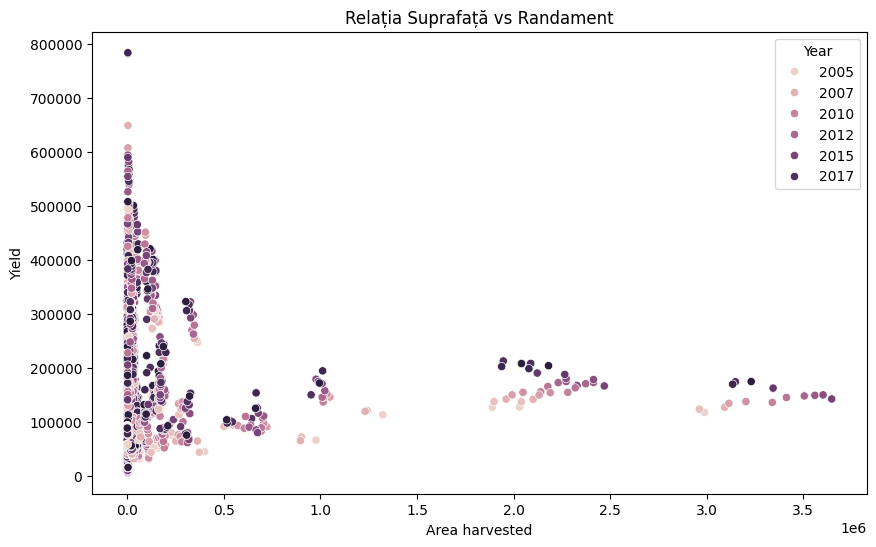

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area harvested', y='Yield', hue='Year')
plt.title("Relația Suprafață vs Randament")
plt.show()

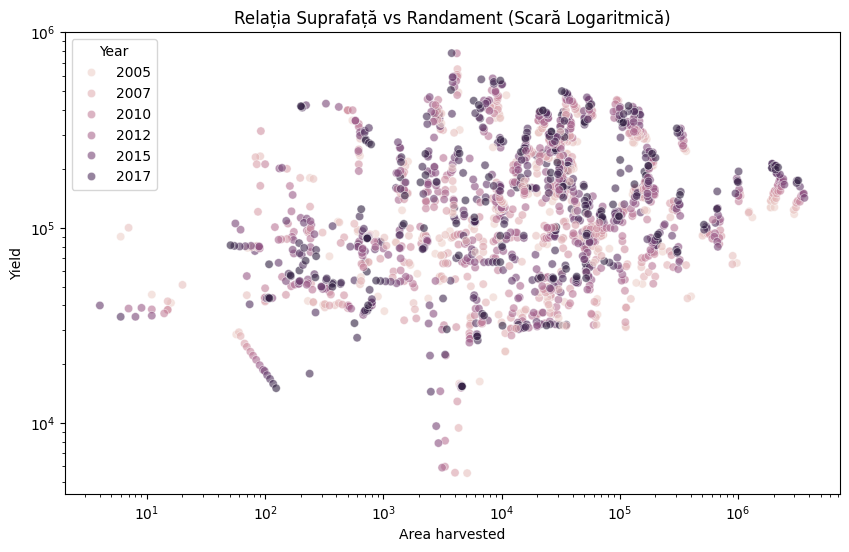

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area harvested', y='Yield', hue='Year', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title("Relația Suprafață vs Randament (Scară Logaritmică)")
plt.show()

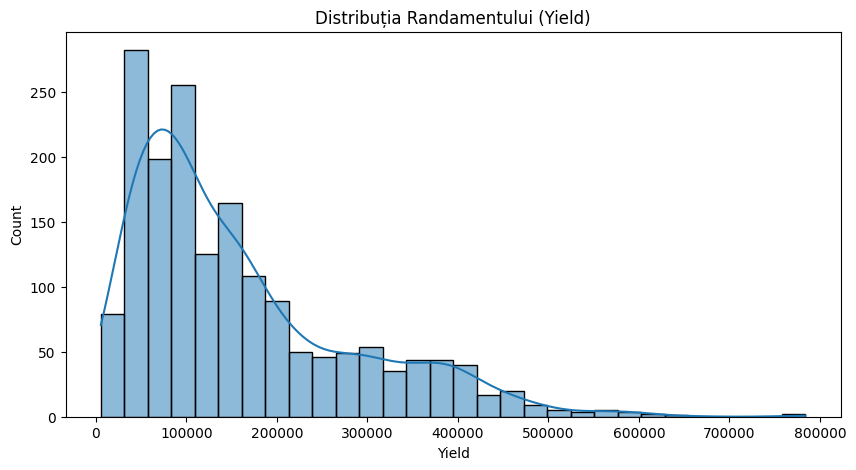

In [47]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Yield'], kde=True, bins=30)
plt.title("Distribuția Randamentului (Yield)")
plt.show()

Daca o sa fie nevoie de log.

<Axes: xlabel='Production_Log', ylabel='Count'>

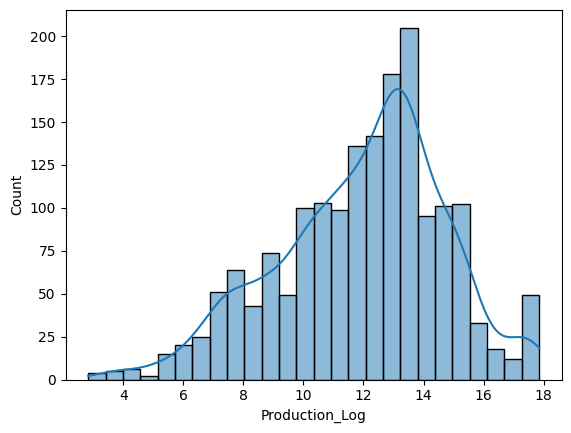

In [48]:
# Aplicăm logaritm (folosim log1p pentru a evita erori la valori de 0)
df['Production_Log'] = np.log1p(df['Production'])

# Verifică noul grafic
sns.histplot(df['Production_Log'], kde=True)

Antrenarea si testarea Modelelor.

In [59]:

base_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Extra Trees": ExtraTreesRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": xgb.XGBRegressor()
}

param_grids = {
    "Linear Regression": {},
    "Ridge" : {
        "alpha" :  uniform(0.01,19.9)
    },
    "Lasso" : {
        "alpha" : uniform(0.01,19.9)
    },
    "Decision Tree": {
        'max_depth': [3, 5, 8, 12, 15, None],
        'min_samples_split': randint(2, 21),
        'min_samples_leaf': randint(1,5),
        'criterion': ['squared_error', 'friedman_mse']
    },
    "Random Forest": {
        'n_estimators': randint(100,801),
        'max_depth': [5, 8, 15, 25, None],
        'min_samples_leaf': randint(1,5),
        'max_features': [None, 'sqrt', 'log2'],
        'bootstrap': [True, False]
    },
    "Extra Trees": {
        'n_estimators': randint(100,501),
        'max_depth': [5, 10, 20, None],  # am modificat adancimea de la 5 la 10 pentru a da mai multă libertate modelului
        'min_samples_split': randint(10, 30 ), # am crescut numărul minim de eșantioane pentru a împiedica overfitting-ul
        'min_samples_leaf': randint(2,8), # fortam frunze mai mari pentru a reduce overfitting-ul
        'bootstrap': [True, False]
    },
    "Gradient Boosting": {
        'n_estimators': randint(100,1001),
        'learning_rate': uniform(0.001,0.099),
        'max_depth': randint(3,7),
        'subsample': uniform(0.6,0.4),
        'n_iter_no_change': [10]
    },
    "AdaBoost": {
        'n_estimators': randint(50,501),
        'learning_rate': uniform(0.01,0.99),
        'loss': ['linear', 'square', 'exponential']
    },
    "XGBoost": {
        'n_estimators':       randint(100, 1001),
        'learning_rate':      uniform(0.01, 0.09),
        'max_depth':          randint(3, 10),
        'subsample':          uniform(0.6, 0.4),
        'colsample_bytree':   uniform(0.6, 0.4),
        'gamma':              uniform(0, 0.2)
    }
}


# Sortează după Area apoi Year - fiecare țară e reprezentată în ambele seturi
df = df.sort_values(['Area', 'Year']).reset_index(drop=True)

X = df.drop(columns=['Yield', 'Production', 'Area harvested', 'Year'], errors='ignore')
y = df['Yield']

encoder = BinaryEncoder(cols=['Area'])
X_encoded = encoder.fit_transform(X)

# Split per țară - 70% primii ani, 30% ultimii ani pentru fiecare țară
def time_split_by_area(df, test_ratio=0.3):
    train_idx, test_idx = [], []
    for area, group in df.groupby('Area'):
        n = len(group)
        split = int(n * (1 - test_ratio))
        train_idx.extend(group.index[:split])
        test_idx.extend(group.index[split:])
    return train_idx, test_idx

train_idx, test_idx = time_split_by_area(df)

x_train33 = X_encoded.loc[train_idx].reset_index(drop=True)
x_test33  = X_encoded.loc[test_idx].reset_index(drop=True)
y_train33 = y.loc[train_idx].reset_index(drop=True)
y_test33  = y.loc[test_idx].reset_index(drop=True)

# TimeSeriesSplit pentru cross-validation
tscv = TimeSeriesSplit(n_splits=5)


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {'bias':<10}| {'MAE':<10}")
print("-" * 100)

results = {}

for name,base in base_models.items():
    params = param_grids[name]

    randomsearch = RandomizedSearchCV(base,params,n_iter=100, cv=tscv,scoring = 'r2',n_jobs=-1,random_state=42)
    model = randomsearch.fit(x_train33,y_train33)

    predictions = model.predict(x_test33)

    train_r2 = model.score(x_train33, y_train33)
    r2 = model.score(x_test33, y_test33)

    bias     = abs(1 - train_r2)
    variance = max(0, train_r2 - r2)
    mae = metrics.mean_absolute_error(y_test33, predictions)


    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   {mae:.2f}" )

    results[name] = {
        "model": model.best_estimator_,
        "r2": r2,
        "mae": mae
    }

Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Linear Regression      | 0.3860   |   0.3850   |  0.0010    |   0.61   |   72728.82


c:\Users\apop3\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=100. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge                  | 0.3852   |   0.3847   |  0.0005    |   0.61   |   72682.97
Lasso                  | 0.3860   |   0.3846   |  0.0013    |   0.61   |   72749.57
Decision Tree          | 0.8551   |   0.5877   |  0.2674    |   0.14   |   51004.11
Random Forest          | 0.9400   |   0.7992   |  0.1407    |   0.06   |   39756.06
Extra Trees            | 0.8326   |   0.7651   |  0.0675    |   0.17   |   44364.26
AdaBoost               | 0.4804   |   0.4596   |  0.0208    |   0.52   |   79959.30
XGBoost                | 0.9135   |   0.7599   |  0.1536    |   0.09   |   45613.34


Alegem primele 3 cele mai bune modele.

In [61]:
top3_names = sorted(results, key=lambda x: results[x]["r2"], reverse=True)[:3]

print("\nTop 3 modele selectate:")
for name in top3_names:
    print(f"  {name:<25} | R2: {results[name]['r2']:.4f} | MAE: {results[name]['mae']:.2f}")

top3_estimators = [(name, results[name]["model"]) for name in top3_names]


Top 3 modele selectate:
  Random Forest             | R2: 0.7992 | MAE: 39756.06
  Extra Trees               | R2: 0.7651 | MAE: 44364.26
  XGBoost                   | R2: 0.7599 | MAE: 45613.34


Facem media rezultatelor celor 3 modele alese.

In [62]:

preds_list = [results[name]["model"].predict(x_test33) for name in top3_names]
avg_preds  = np.mean(preds_list, axis=0)
avg_r2     = metrics.r2_score(y_test33, avg_preds)
avg_mae    = metrics.mean_absolute_error(y_test33, avg_preds)

print(f"Averaging | R2: {avg_r2:.4f} | MAE: {avg_mae:.2f}")

Averaging | R2: 0.7818 | MAE: 42668.01


Se alege modelul cel mai bun printr-un sistem de voting.

In [63]:
top3_estimators = [(name, results[name]["model"]) for name in top3_names]
weights = [results[name]["r2"] for name in top3_names]

voting = VotingRegressor(estimators=top3_estimators, weights=weights)
voting.fit(x_train33, y_train33)

v_preds = voting.predict(x_test33)
v_r2    = metrics.r2_score(y_test33, v_preds)
v_mae   = metrics.mean_absolute_error(y_test33, v_preds)

print(f"Voting Weighted | R2: {v_r2:.4f} | MAE: {v_mae:.2f}")

Voting Weighted | R2: 0.7834 | MAE: 42559.20


In loc să combini predicțiile prin medie sau vot, antrenezi un model nou care învață cum să le combine.

In [65]:
top3_estimators = [(name, results[name]["model"]) for name in top3_names]

stacking = StackingRegressor(
    estimators=top3_estimators,
    final_estimator=RidgeCV(),
    cv=5,
    passthrough=False
)

stacking.fit(x_train33, y_train33)

s_preds = stacking.predict(x_test33)
s_r2    = metrics.r2_score(y_test33, s_preds)
s_mae   = metrics.mean_absolute_error(y_test33, s_preds)

print(f"Stacking | R2: {s_r2:.4f} | MAE: {s_mae:.2f}")

Stacking | R2: 0.7520 | MAE: 44559.30
